# Predicting Major Interventions through Network Medicine using Machine Learning

By: Ori Shai & Osnat Blau

Develop a comprehensive clinical predictive modeling workflow using MIMIC-IV data. This includes ensuring data consistency and target definition, performing Exploratory Data Analysis with correlation heatmaps and network graphs, conducting K-Means clustering for patient archetyping, training and evaluating unified Random Forest and XGBoost models, performing gender-stratified performance analysis, and creating an interactive dashboard to summarize the final clinical insights.

## Environment Setup & Imports

In [ ]:
!pip install imbalanced-learn shap pytest -q

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from google.colab import drive
import requests
import json
from matplotlib.patches import Patch
from IPython.display import HTML, display

from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedGroupKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, precision_recall_curve
from sklearn.manifold import TSNE
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, RocCurveDisplay


from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import shap
import ipywidgets as widgets
from IPython.display import clear_output


from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, roc_auc_score, precision_recall_curve,
    auc, f1_score, brier_score_loss, balanced_accuracy_score
)

import warnings
warnings.filterwarnings('ignore')

## Data Loading & Basic Cleaning

### load files from drive

In [ ]:
drive.mount('/content/drive', force_remount=True)

SOURCE_DIR = '/content/drive/MyDrive/MIMIC_IV_data/'
DEST_DIR = '/content/'

files_to_copy = {
    'diagnoses_icd.csv': os.path.join(SOURCE_DIR, 'diagnoses_icd.csv'),
    'procedures_icd.csv': os.path.join(SOURCE_DIR, 'procedures_icd.csv'),
    'd_icd_diagnoses.csv': os.path.join(SOURCE_DIR, 'd_icd_diagnoses.csv'),
    'd_icd_procedures.csv': os.path.join(SOURCE_DIR, 'd_icd_procedures.csv'),
    'patients.csv': '/content/drive/MyDrive/patients.csv'
}

for file_name, source_path in files_to_copy.items():
    dest_path = os.path.join(DEST_DIR, file_name)
    if os.path.exists(source_path):
        os.system(f'cp "{source_path}" "{dest_path}"')
        print(f"Copied {file_name}")

# Load dataframes
df_diagnoses = pd.read_csv('diagnoses_icd.csv').drop_duplicates(subset=['hadm_id', 'icd_code']).dropna(subset=['hadm_id', 'icd_code'])
df_procedures = pd.read_csv('procedures_icd.csv').drop_duplicates(subset=['hadm_id', 'icd_code'])
df_dict_diag = pd.read_csv('d_icd_diagnoses.csv').drop_duplicates()
df_dict_proc = pd.read_csv('d_icd_procedures.csv').drop_duplicates()
df_patients = pd.read_csv('patients.csv').dropna(subset=['subject_id', 'gender'])

# Impute Missing Age using Median
if df_patients['anchor_age'].isnull().any():
    median_age = df_patients['anchor_age'].median()
    df_patients['anchor_age'] = df_patients['anchor_age'].fillna(median_age)

# Filter valid ages
df_patients = df_patients[(df_patients['anchor_age'] >= 18) & (df_patients['anchor_age'] <= 100)]
print('\nData loading and cleaning step complete.')

Mounted at /content/drive
Copied diagnoses_icd.csv
Copied procedures_icd.csv
Copied d_icd_diagnoses.csv
Copied d_icd_procedures.csv
Copied patients.csv

Data loading and cleaning step complete.


In [ ]:
print('--- Diagnoses ICD ---')
display(df_diagnoses.head())

print('\n--- Procedures ICD ---')
display(df_procedures.head())

print('\n--- Patients ---')
display(df_patients.head())

print('\n--- ICD Diagnoses Dictionary ---')
display(df_dict_diag.head())

print('\n--- ICD Procedures Dictionary ---')
display(df_dict_proc.head())


--- Diagnoses ICD ---


,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10000032,22595853,1,5723,9
1,10000032,22595853,2,78959,9
2,10000032,22595853,3,5715,9
3,10000032,22595853,4,07070,9
4,10000032,22595853,5,496,9



--- Procedures ICD ---


,subject_id,hadm_id,seq_num,chartdate,icd_code,icd_version
0,10000032,22595853,1,2180-05-07,5491,9
1,10000032,22841357,1,2180-06-27,5491,9
2,10000032,25742920,1,2180-08-06,5491,9
3,10000068,25022803,1,2160-03-03,8938,9
4,10000117,27988844,1,2183-09-19,0QS734Z,10



--- Patients ---


,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13



--- ICD Diagnoses Dictionary ---


,icd_code,icd_version,long_title
0,0010,9,Cholera due to vibrio cholerae
1,0011,9,Cholera due to vibrio cholerae el tor
2,0019,9,"Cholera, unspecified"
3,0020,9,Typhoid fever
4,0021,9,Paratyphoid fever A



--- ICD Procedures Dictionary ---


,icd_code,icd_version,long_title
0,0001,9,Therapeutic ultrasound of vessels of head and ...
1,0002,9,Therapeutic ultrasound of heart
2,0003,9,Therapeutic ultrasound of peripheral vascular ...
3,0009,9,Other therapeutic ultrasound
4,001,10,"Central Nervous System and Cranial Nerves, Bypass"


### Feature Engineering & Target Definition

In [ ]:
# Diagnoses Matrix
diag_merged = pd.merge(df_diagnoses, df_dict_diag, on=['icd_code', 'icd_version'], how='inner')
top_50_diagnoses = diag_merged['long_title'].value_counts().head(50).index
df_x = pd.crosstab(diag_merged[diag_merged['long_title'].isin(top_50_diagnoses)]['hadm_id'],
                   diag_merged[diag_merged['long_title'].isin(top_50_diagnoses)]['long_title']).astype(int).reset_index()

# Target Variable (Top 20 Procedures)
proc_merged = pd.merge(df_procedures, df_dict_proc, on=['icd_code', 'icd_version'], how='inner')
top_20_procs = proc_merged['long_title'].value_counts().head(20).index
target_map = proc_merged[proc_merged['long_title'].isin(top_20_procs)][['hadm_id']].drop_duplicates()
target_map['target'] = 1

# Demographics
df_demo = df_patients[['subject_id', 'gender', 'anchor_age']].copy()
df_demo['gender_binary'] = (df_demo['gender'] == 'M').astype(int)
df_demo.rename(columns={'anchor_age': 'age'}, inplace=True)

# Merge Components
hadm_subject_map = df_diagnoses[['hadm_id', 'subject_id']].drop_duplicates()
combined_features = pd.merge(df_x, hadm_subject_map, on='hadm_id', how='inner')
combined_features = pd.merge(combined_features, df_demo, on='subject_id', how='inner')

final_dataset = pd.merge(combined_features, target_map, on='hadm_id', how='left').fillna(0)
final_dataset.set_index('hadm_id', inplace=True)

# Comorbidity Interaction Engineering
if 'Acute kidney failure, unspecified' in final_dataset.columns and 'Congestive heart failure, unspecified' in final_dataset.columns:
    final_dataset['weight_cardiorenal'] = final_dataset['Acute kidney failure, unspecified'] * final_dataset['Congestive heart failure, unspecified']

metabolic_cols = ['Unspecified essential hypertension', 'Hyperlipidemia, unspecified', 'Diabetes mellitus without mention of complication, type II or unspecified type, not stated as uncontrolled']
valid_metabolic = [c for c in metabolic_cols if c in final_dataset.columns]
if len(valid_metabolic) > 1:
    final_dataset['weight_metabolic'] = final_dataset[valid_metabolic].sum(axis=1) / len(valid_metabolic)

psych_cols = ['Major depressive disorder, single episode, unspecified', 'Anxiety disorder, unspecified']
valid_psych = [c for c in psych_cols if c in final_dataset.columns]
if len(valid_psych) > 1:
    final_dataset['weight_psychosocial'] = final_dataset[valid_psych].product(axis=1)

print(f"Final Dataset Ready. Shape: {final_dataset.shape}, Target Rate: {final_dataset['target'].mean():.2%}")

Final Dataset Ready. Shape: (461946, 58), Target Rate: 18.79%


In [ ]:
print("--- df merged ---")
display(diag_merged.head())

--- df merged ---


,subject_id,hadm_id,seq_num,icd_code,icd_version,long_title
0,10000032,22595853,1,5723,9,Portal hypertension
1,10000032,22595853,2,78959,9,Other ascites
2,10000032,22595853,3,5715,9,Cirrhosis of liver without mention of alcohol
3,10000032,22595853,4,07070,9,Unspecified viral hepatitis C without hepatic ...
4,10000032,22595853,5,496,9,"Chronic airway obstruction, not elsewhere clas..."


## Exploratory Data Analysis (EDA) - Bar Plots & Heatmaps

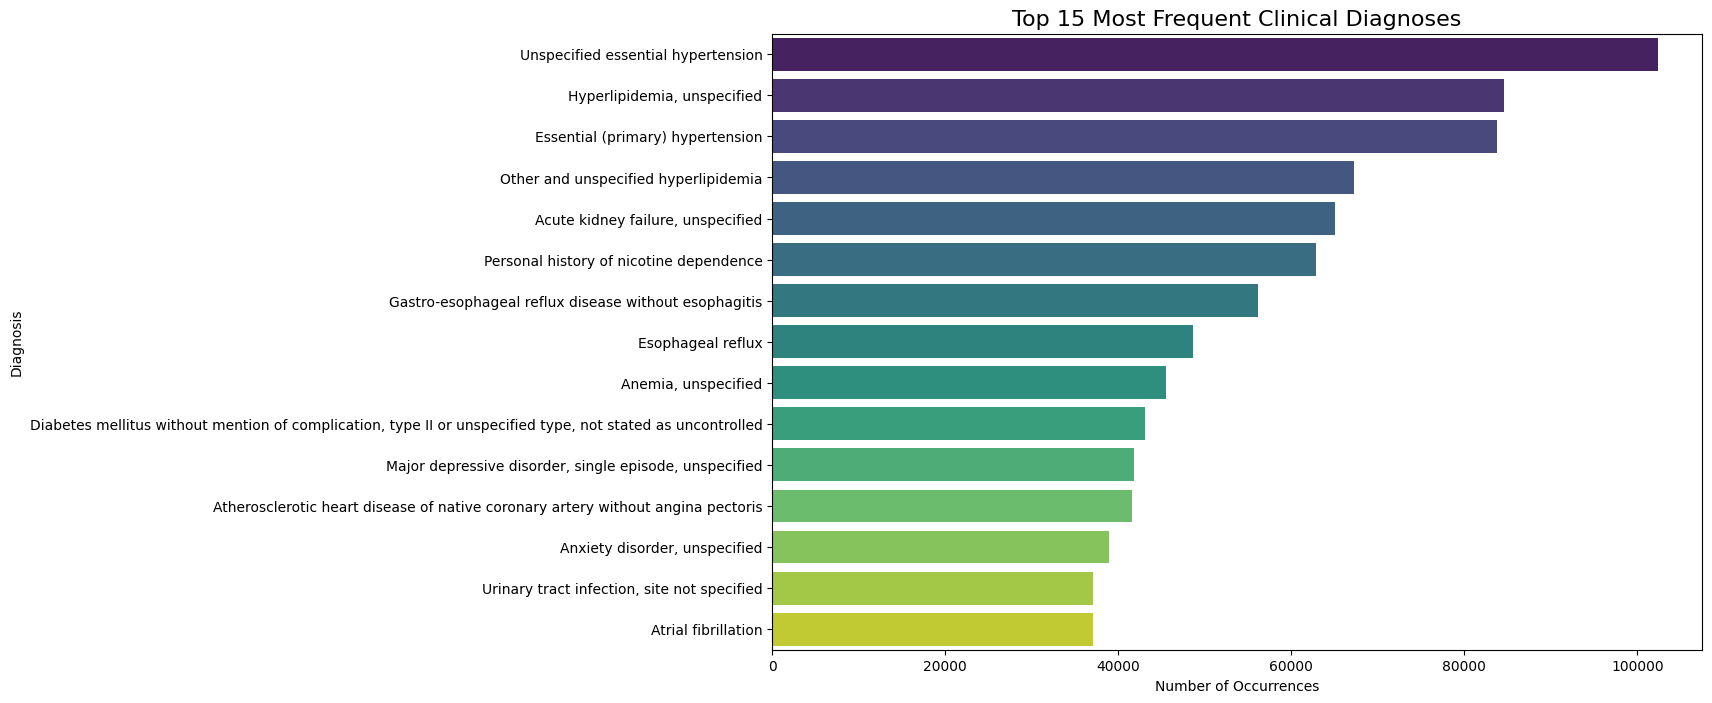

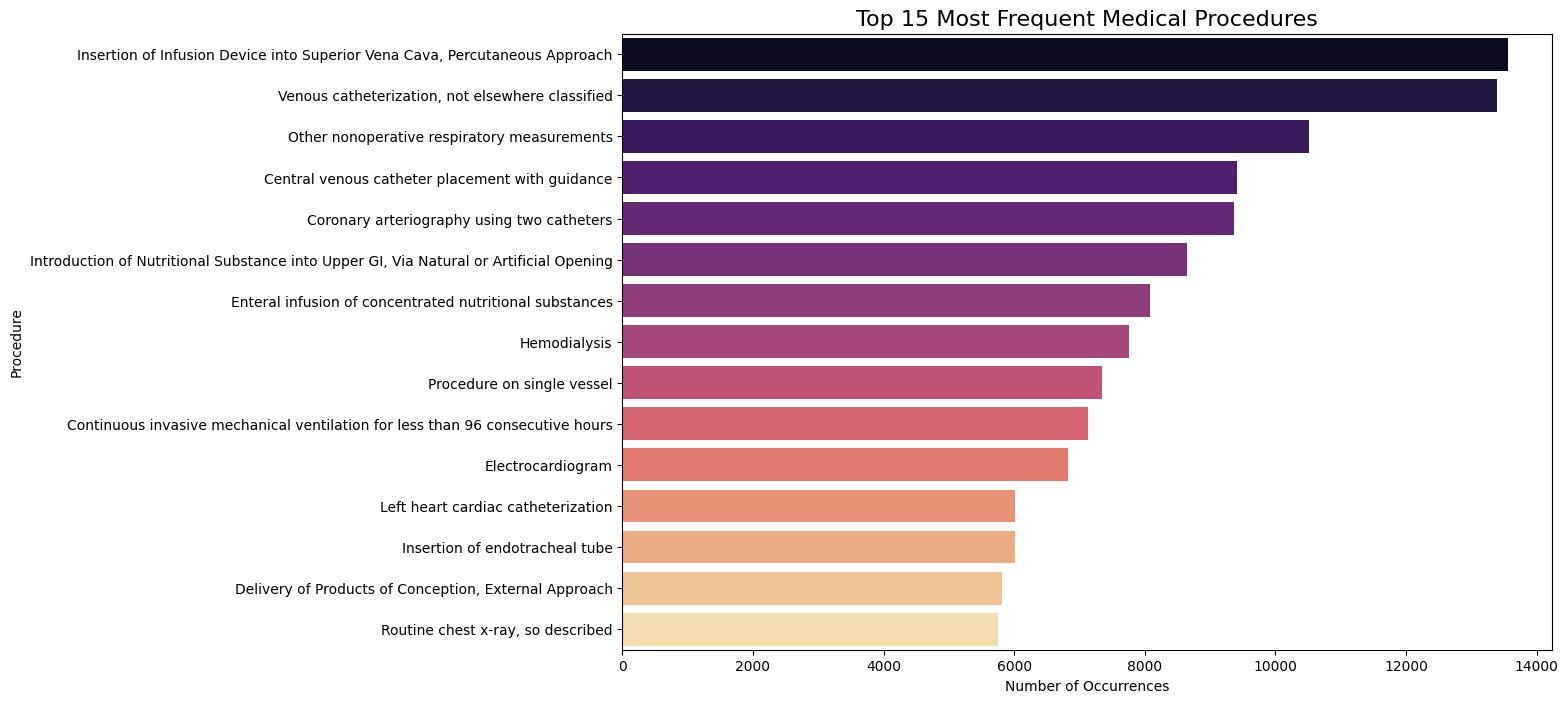

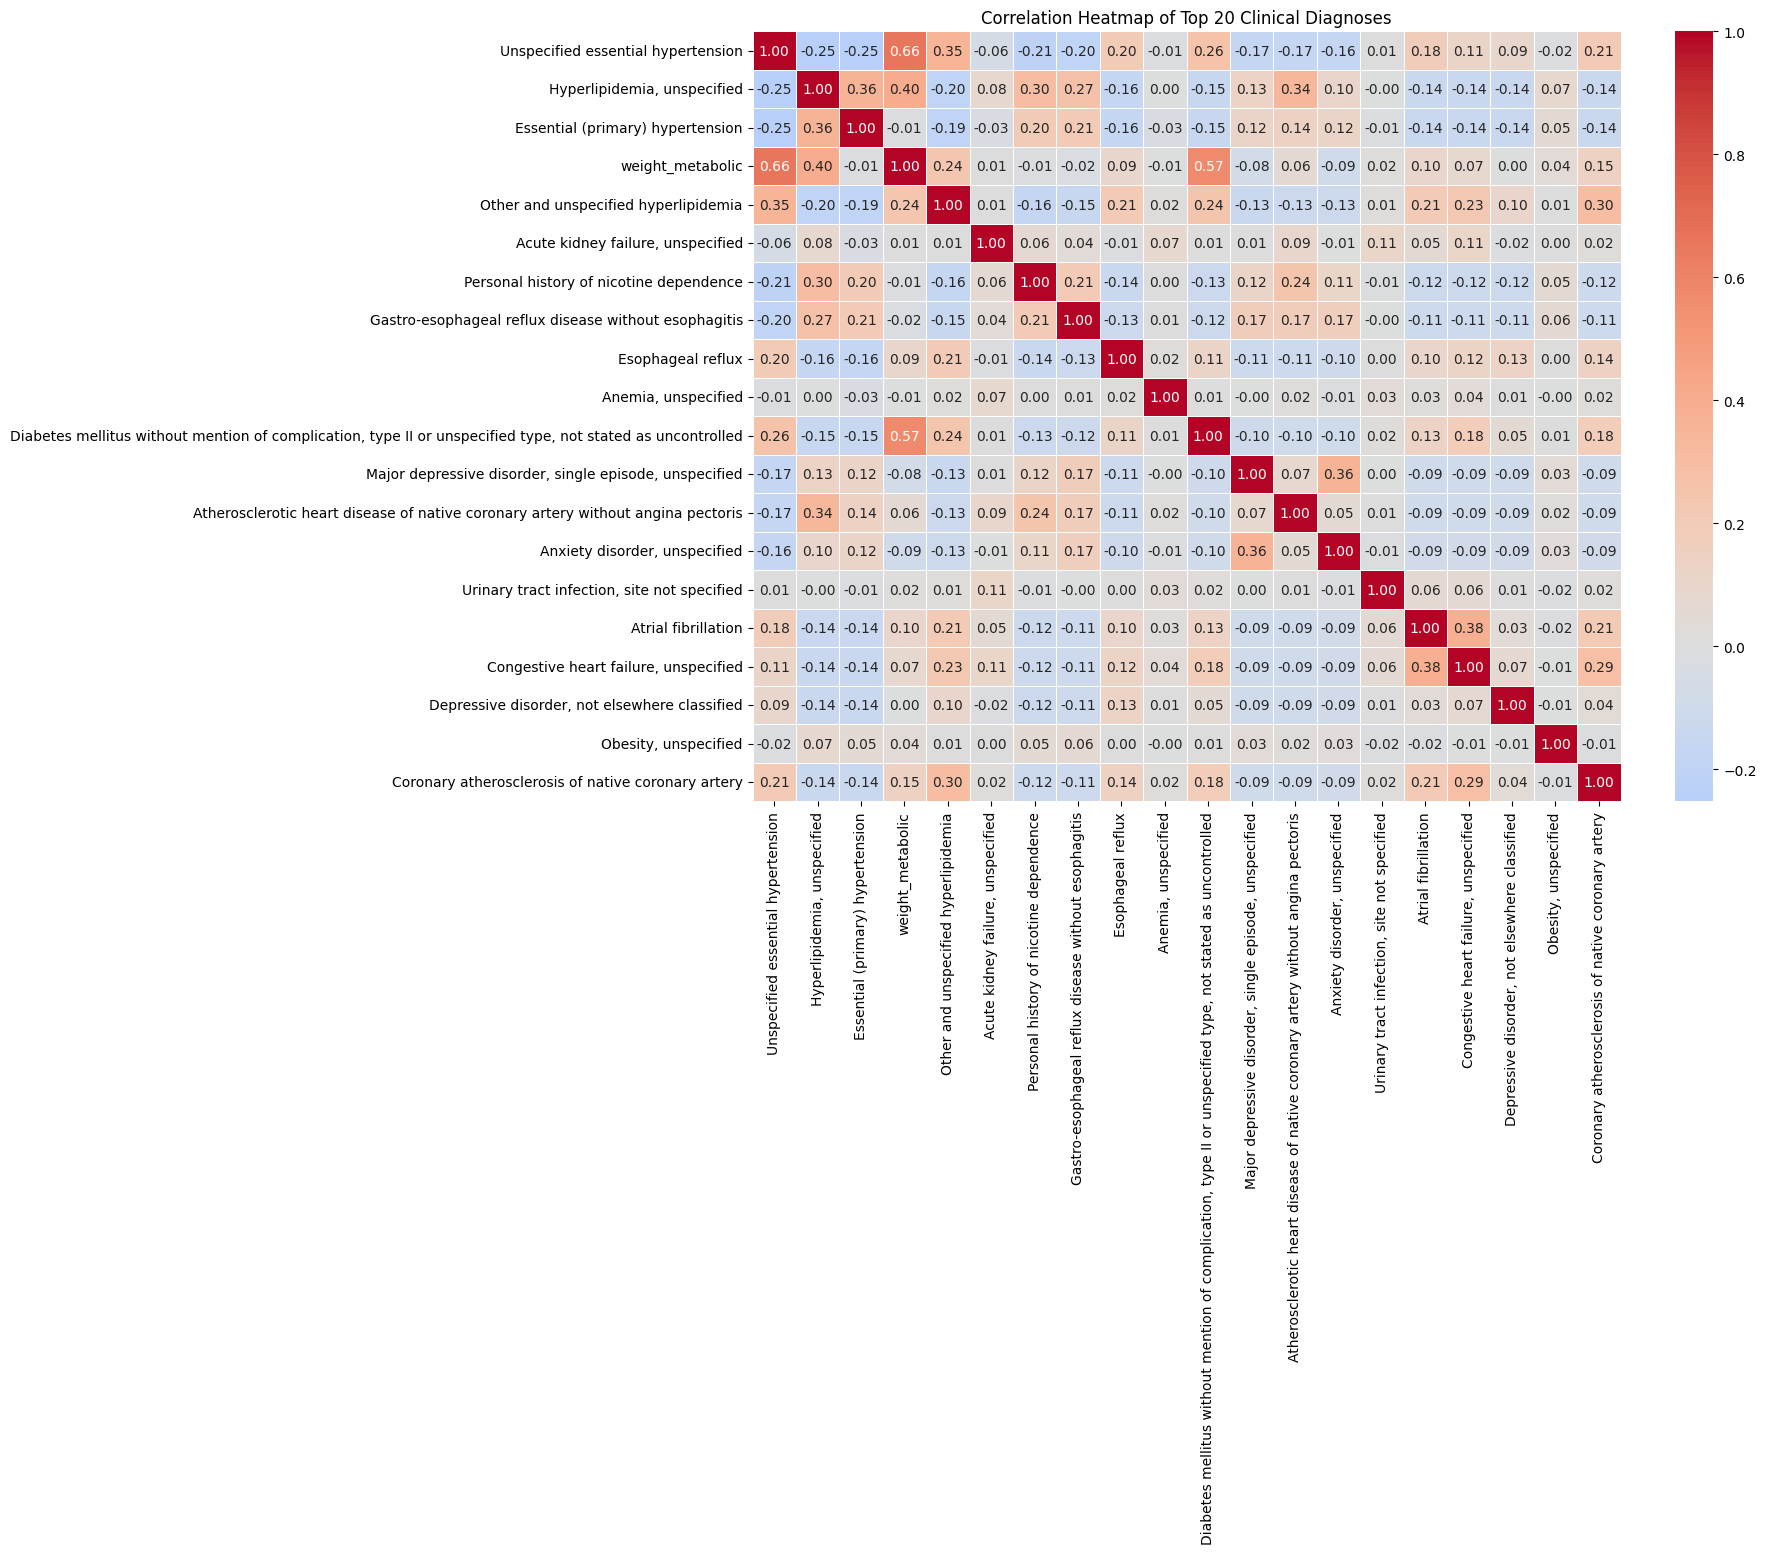

In [ ]:
# 1. Plot Top 15 Diagnoses
diagnosis_counts = diag_merged['long_title'].value_counts().head(15)
plt.figure(figsize=(12, 8))
sns.barplot(y=diagnosis_counts.index, x=diagnosis_counts.values, palette='viridis')
plt.title('Top 15 Most Frequent Clinical Diagnoses', fontsize=16)
plt.xlabel('Number of Occurrences'), plt.ylabel('Diagnosis')
plt.show()

# 2. Plot Top 15 Procedures
procedure_counts = proc_merged['long_title'].value_counts().head(15)
plt.figure(figsize=(12, 8))
sns.barplot(y=procedure_counts.index, x=procedure_counts.values, palette='magma')
plt.title('Top 15 Most Frequent Medical Procedures', fontsize=16)
plt.xlabel('Number of Occurrences'), plt.ylabel('Procedure')
plt.show()

# 3. Correlation Matrix Heatmap
exclude_cols = ['age', 'gender_binary', 'target', 'subject_id', 'cluster', 'pca_1', 'pca_2']
diag_cols = [c for c in final_dataset.columns if c not in exclude_cols and final_dataset[c].dtype in ['int64', 'float64', 'int32']]
top_20_diag_names = final_dataset[diag_cols].sum().sort_values(ascending=False).head(20).index.tolist()
corr_matrix = final_dataset[top_20_diag_names].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=.5)
plt.title('Correlation Heatmap of Top 20 Clinical Diagnoses')
plt.show()

### Heatmap of strongest clusters

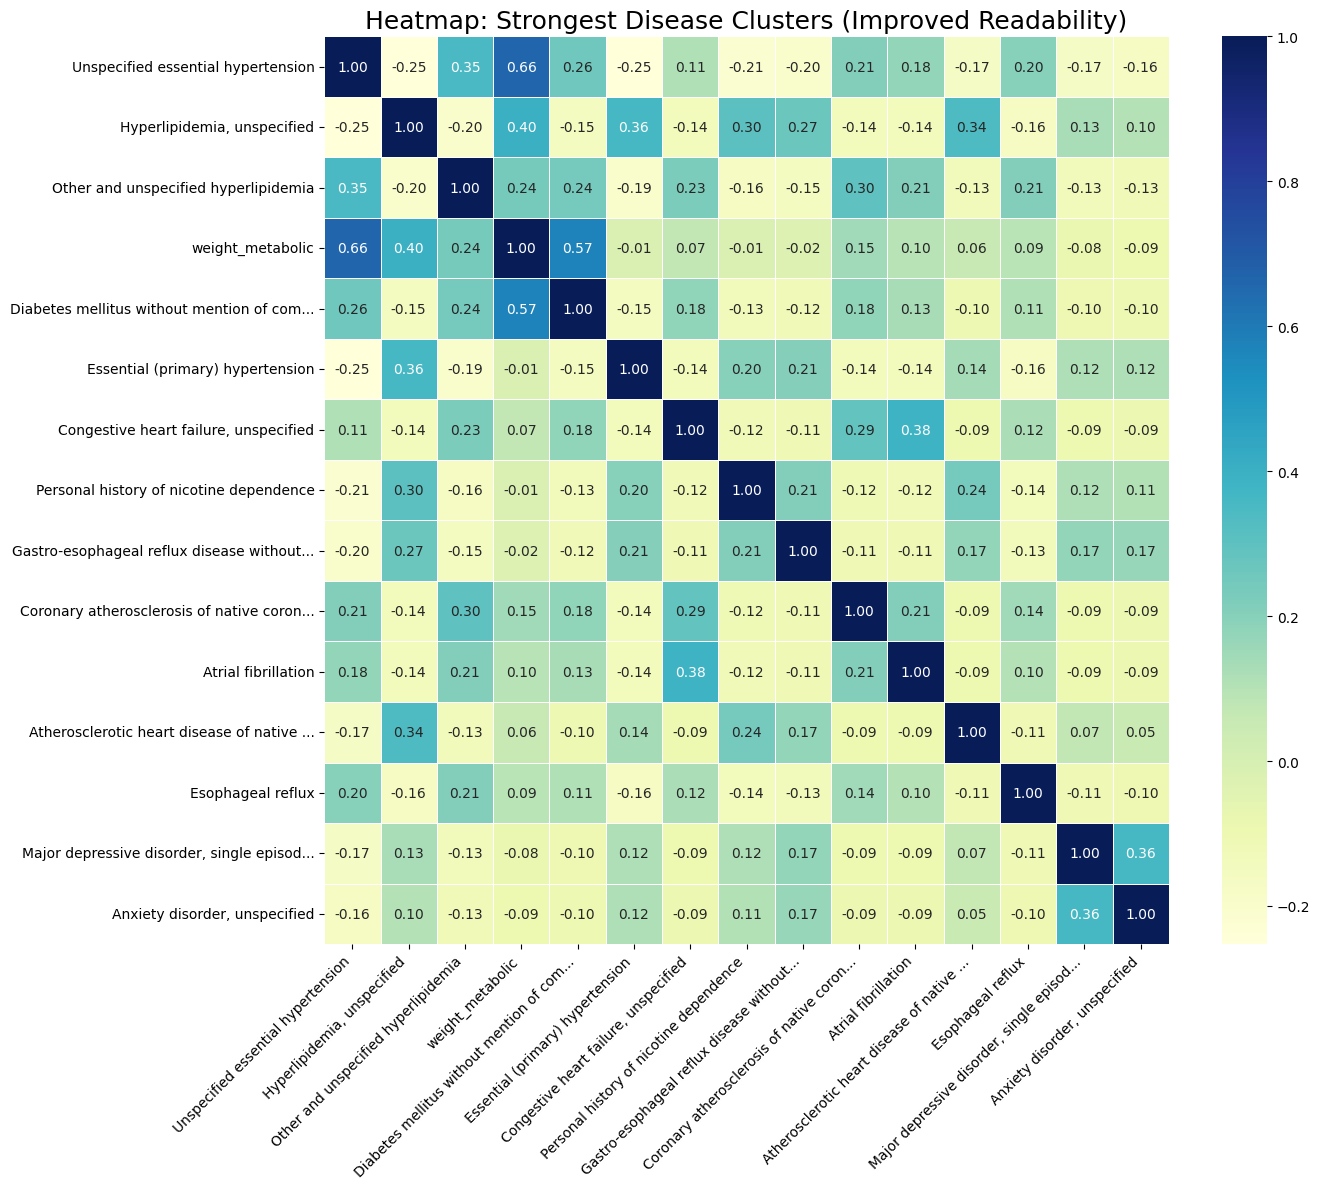

In [ ]:
# Heatmap of strongest clusters
top_correlated_features = corr_matrix.abs().mean().sort_values(ascending=False).head(15).index
subset_corr = corr_matrix.loc[top_correlated_features, top_correlated_features]

# Truncate long labels for readability
short_labels = [c[:40] + '...' if len(c) > 40 else c for c in subset_corr.columns]
subset_corr.columns = short_labels
subset_corr.index = short_labels

plt.figure(figsize=(14, 12))
sns.heatmap(subset_corr, annot=True, fmt='.2f', cmap='YlGnBu', linewidths=0.5, annot_kws={"size": 10})

plt.title('Heatmap: Strongest Disease Clusters (Improved Readability)', fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### Disease Co-occurrence Network Graph

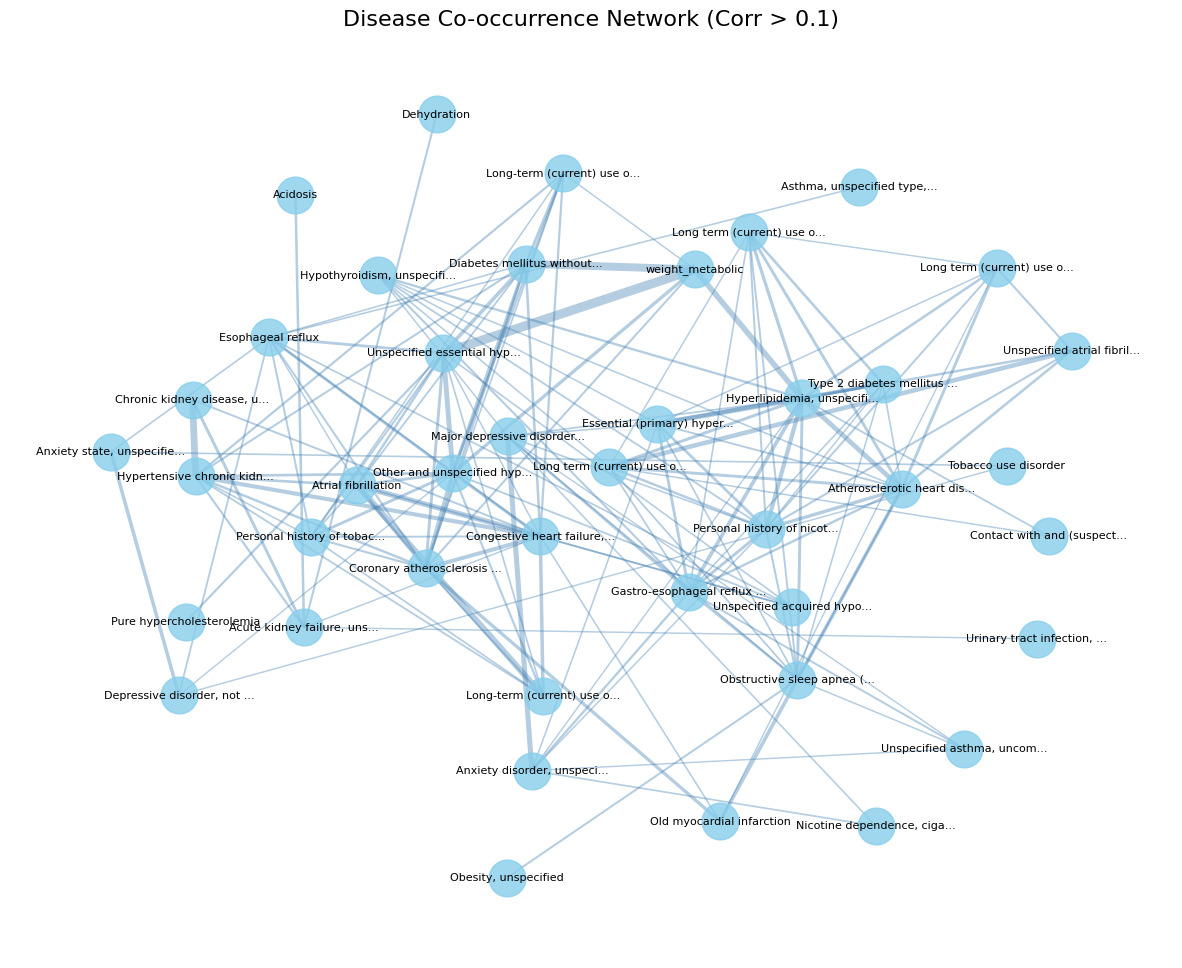

In [ ]:
# === CELL 5: Disease Co-occurrence Network Graph ===
top_50_diag_names = final_dataset[diag_cols].sum().sort_values(ascending=False).head(50).index.tolist()
corr_matrix_50 = final_dataset[top_50_diag_names].corr()

corr_unstacked = corr_matrix_50.unstack().reset_index()
corr_unstacked.columns = ['Diagnosis A', 'Diagnosis B', 'Correlation']
corr_pairs = corr_unstacked[corr_unstacked['Diagnosis A'] != corr_unstacked['Diagnosis B']]

threshold = 0.1
strong_links = corr_pairs[corr_pairs['Correlation'] > threshold]

G = nx.Graph()
for _, row in strong_links.iterrows():
    G.add_edge(row['Diagnosis A'], row['Diagnosis B'], weight=row['Correlation'])

if G.number_of_nodes() > 0:
    plt.figure(figsize=(15, 12))
    pos = nx.spring_layout(G, k=0.8, seed=42)
    labels = {node: (node[:25] + '...') if len(node) > 25 else node for node in G.nodes()}
    weights = [G[u][v]['weight'] * 10 for u, v in G.edges()]
    nx.draw_networkx_nodes(G, pos, node_size=700, node_color='skyblue', alpha=0.8)
    nx.draw_networkx_edges(G, pos, width=weights, edge_color='steelblue', alpha=0.4)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_family='sans-serif')
    plt.title(f'Disease Co-occurrence Network (Corr > {threshold})', fontsize=16)
    plt.axis('off')
    plt.show()

### Unsupervised Archetyping (K-Means, PCA, t-SNE & Scree Plot)

K-Means clustering complete. Archetype distribution:
cluster
2    228456
1    114938
0    101675
3     16877
Name: count, dtype: int64


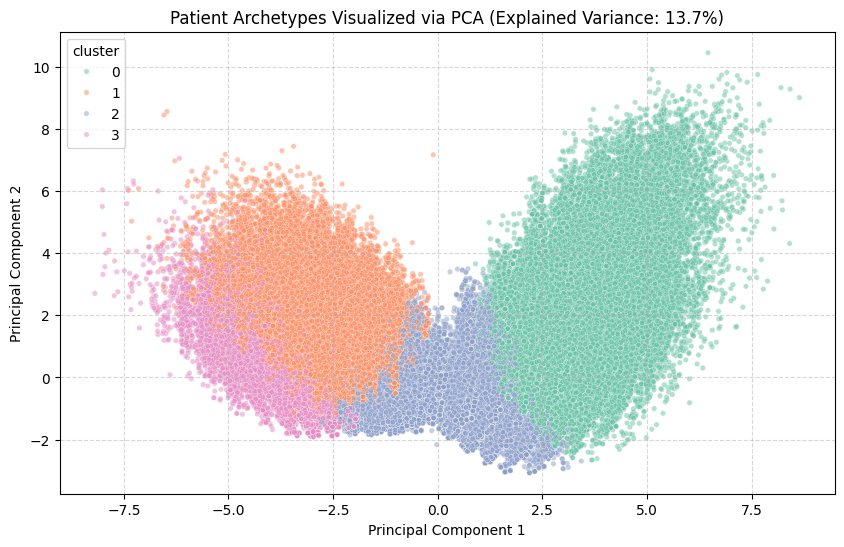

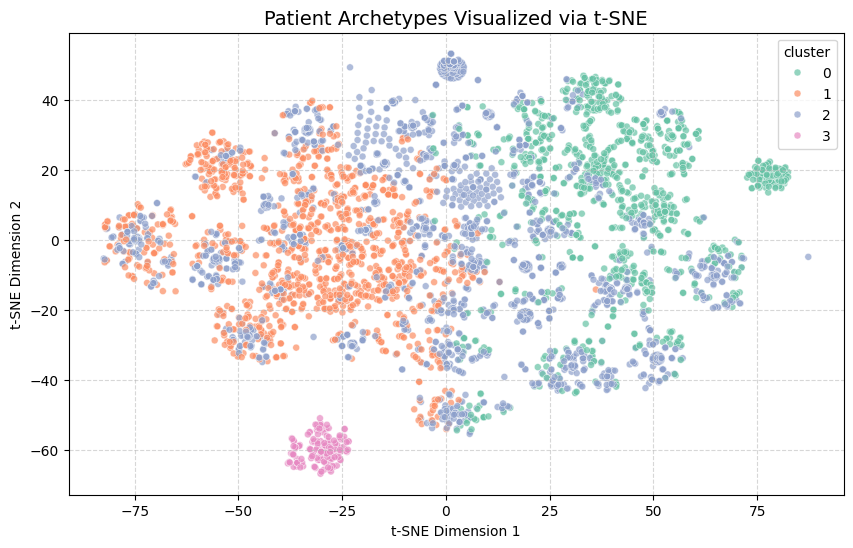

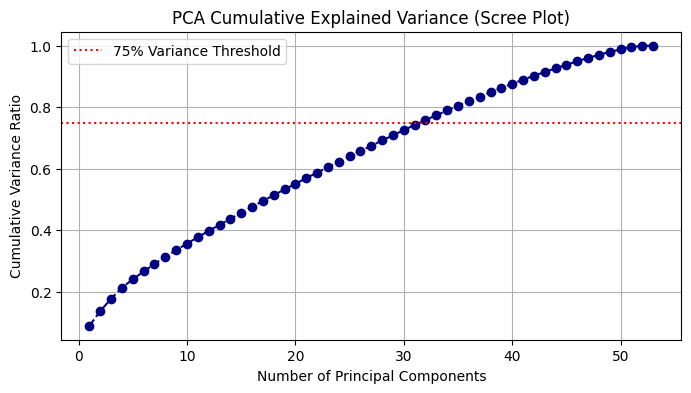

In [ ]:

# 1. Scaling & Feature Selection for Clustering
# Ensure we exclude ALL non-numeric and metadata columns explicitly
exclude_from_clustering = ['age', 'gender_binary', 'target', 'subject_id', 'cluster', 'pca_1', 'pca_2', 'gender']
diag_cols = [c for c in final_dataset.columns if c not in exclude_from_clustering and final_dataset[c].dtype in ['int64', 'float64', 'int32']]

X_cluster = final_dataset[diag_cols].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 2. K-Means Clustering (k=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
final_dataset['cluster'] = kmeans.fit_predict(X_scaled)
print("K-Means clustering complete. Archetype distribution:")
print(final_dataset['cluster'].value_counts())

# 3. 2D PCA Projection
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
final_dataset['pca_1'] = pca_coords[:, 0]
final_dataset['pca_2'] = pca_coords[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='pca_1', y='pca_2', hue='cluster', data=final_dataset, palette='Set2', alpha=0.5, s=15)
plt.title(f'Patient Archetypes Visualized via PCA (Explained Variance: {pca.explained_variance_ratio_.sum():.1%})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 4. t-SNE Visualization (Enhanced Non-linear Separation)
np.random.seed(42)
sample_size = min(5000, len(X_scaled))
sample_idx = np.random.choice(X_scaled.shape[0], size=sample_size, replace=False)
X_sample = X_scaled[sample_idx]
cluster_sample = final_dataset['cluster'].iloc[sample_idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=cluster_sample, palette='Set2', alpha=0.7, s=25)
plt.title('Patient Archetypes Visualized via t-SNE', fontsize=14)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 5. Scree Plot Analysis (Cumulative Explained Variance)
pca_full = PCA().fit(X_scaled)
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumsum_var) + 1), cumsum_var, marker='o', linestyle='--', color='navy')
plt.axhline(y=0.75, color='r', linestyle=':', label='75% Variance Threshold')
plt.title('PCA Cumulative Explained Variance (Scree Plot)', fontsize=12)
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Ratio')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Identify diagnostic columns (binary indicators)
exclude_cols = ['age', 'gender_binary', 'target', 'subject_id', 'cluster', 'pca_1', 'pca_2', 'gender']
diag_cols = [c for c in final_dataset.columns if c not in exclude_cols and final_dataset[c].dtype in ['int64', 'float64', 'int32']]

# Calculate the prevalence of each diagnosis per cluster
cluster_profiles = final_dataset.groupby('cluster')[diag_cols].mean()

print("--- Top 5 Diagnoses per Cluster (Prevalence) ---")
for cluster_id in sorted(final_dataset['cluster'].unique()):
    print(f"\nCluster {cluster_id} Profile:")
    top_diags = cluster_profiles.loc[cluster_id].sort_values(ascending=False).head(5)
    for diag, val in top_diags.items():
        print(f" - {diag}: {val:.1%}")

print("\n--- Clinical Interpretation ---")
print("Cluster 0: Metabolic Syndrome (Hypertension/Diabetes focus)")
print("Cluster 1: Acute Cardiorenal (Heart Failure/Kidney Failure focus)")
print("Cluster 2: General Population (Mixed chronic conditions)")
print("Cluster 3: Behavioral & Lifestyle Factors (Tobacco use / Psychosocial focus)")

--- Top 5 Diagnoses per Cluster (Prevalence) ---

Cluster 0 Profile:
 - Unspecified essential hypertension: 60.5%
 - Other and unspecified hyperlipidemia: 51.5%
 - Diabetes mellitus without mention of complication, type II or unspecified type, not stated as uncontrolled: 38.4%
 - weight_metabolic: 33.0%
 - Congestive heart failure, unspecified: 32.7%

Cluster 1 Profile:
 - Hyperlipidemia, unspecified: 66.1%
 - Essential (primary) hypertension: 48.6%
 - Personal history of nicotine dependence: 39.4%
 - Gastro-esophageal reflux disease without esophagitis: 33.0%
 - Atherosclerotic heart disease of native coronary artery without angina pectoris: 32.1%

Cluster 2 Profile:
 - Unspecified essential hypertension: 17.9%
 - Essential (primary) hypertension: 9.9%
 - Depressive disorder, not elsewhere classified: 9.4%
 - Esophageal reflux: 8.8%
 - Anemia, unspecified: 8.6%

Cluster 3 Profile:
 - Anxiety disorder, unspecified: 100.0%
 - weight_psychosocial: 100.0%
 - Major depressive disorder, sin

### Radar Chart for Clinical Profiles

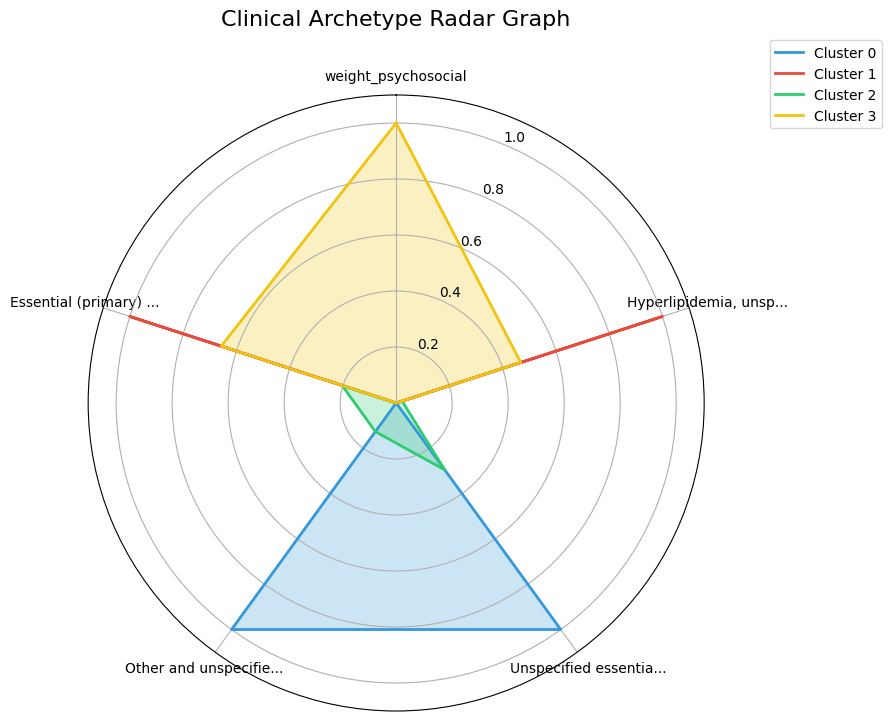

In [ ]:
# === CELL 7: Radar Chart for Clinical Profiles ===
features_for_radar = [c for c in final_dataset.columns if 'weight_' in c] + top_20_diag_names[:5]
cluster_summary = final_dataset.groupby('cluster')[features_for_radar].mean().T
top_radar_features = cluster_summary.var(axis=1).sort_values(ascending=False).head(5).index.tolist()
data_radar = cluster_summary.loc[top_radar_features]
data_radar_norm = data_radar.div(data_radar.max(axis=1), axis=0).fillna(0)

labels = [f[:20] + '...' if len(f) > 20 else f for f in top_radar_features]
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f1c40f']
cluster_names = [f'Cluster {i}' for i in range(4)]

for i, cluster_id in enumerate(sorted(final_dataset['cluster'].unique())):
    values = data_radar_norm[cluster_id].values.tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors[i], linewidth=2, label=cluster_names[i])
    ax.fill(angles, values, color=colors[i], alpha=0.25)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(0, 1.1)
plt.title('Clinical Archetype Radar Graph', size=16, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

## Unified Predictive Modeling (Random Forest & XGBoost)

In [ ]:
# === Unified Predictive Modeling with Calibration & Imbalance Handling ===

# 1. Drop metadata and define Target
# Explicitly added 'gender' (string) to drop_cols to avoid conversion errors
drop_cols = ['target', 'subject_id', 'cluster', 'pca_1', 'pca_2', 'gender']
X_all = final_dataset.drop(columns=drop_cols, errors='ignore')
y = final_dataset['target']

# 2. Feature Selection using Chi-Square (Top 50)
chi2_selector = SelectKBest(score_func=chi2, k=50)
X_kbest = chi2_selector.fit_transform(X_all, y)
selected_features = X_all.columns[chi2_selector.get_support()]
X_top_50 = X_all[selected_features]

print(f"Top 50 selected features via Chi-Square complete. Feature space shape: {X_top_50.shape}")

# 3. Group-Aware Splitting to prevent data leakage (by subject_id)
groups = final_dataset['subject_id']
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(sgkf.split(X_top_50, y, groups=groups))

X_train, X_test = X_top_50.iloc[train_idx], X_top_50.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Advanced patient-aware train/test split complete. Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# 4. Logistic Regression Baseline
lr_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
y_probs_lr = lr_pipeline.predict_proba(X_test)[:, 1]
print("\n--- Logistic Regression Baseline ---")
print(classification_report(y_test, y_pred_lr))

# 5. Calibrated XGBoost Classifier (Isotonic Regression for Risk Calibration)
base_xgb = XGBClassifier(random_state=42, eval_metric='logloss', n_estimators=100)
calibrated_xgb = CalibratedClassifierCV(estimator=base_xgb, method='isotonic', cv=3)

xgb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', calibrated_xgb)
])

xgb_pipeline.fit(X_train, y_train)
y_probs_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]
y_pred_default_xgb = xgb_pipeline.predict(X_test)

# 6. Comprehensive Metrics for Imbalanced Data
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_xgb)
pr_auc = auc(recall, precision)
brier = brier_score_loss(y_test, y_probs_xgb)
roc_auc = roc_auc_score(y_test, y_probs_xgb)

print("\n--- Calibrated XGBoost Performance Summary ---")
print(f"ROC-AUC Score: {roc_auc:.3f}")
print(f"PR-AUC (Precision-Recall AUC): {pr_auc:.3f}")
print(f"Brier Score (Calibration Reliability): {brier:.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_default_xgb):.3f}")

# 7. Operational Threshold Tuning for Triage Escalation (Threshold = 0.37)
opt_threshold = 0.37
y_pred_custom = (y_probs_xgb >= opt_threshold).astype(int)
print(f"\n--- Performance at Operational Threshold ({opt_threshold}) ---")
print(f"F1-Score: {f1_score(y_test, y_pred_custom):.3f}")

Top 50 selected features via Chi-Square complete. Feature space shape: (461946, 50)
Advanced patient-aware train/test split complete. Train shape: (370436, 50), Test shape: (91510, 50)

--- Logistic Regression Baseline ---
              precision    recall  f1-score   support

         0.0       0.87      0.66      0.75     74391
         1.0       0.27      0.56      0.36     17119

    accuracy                           0.64     91510
   macro avg       0.57      0.61      0.56     91510
weighted avg       0.75      0.64      0.67     91510


--- Calibrated XGBoost Performance Summary ---
ROC-AUC Score: 0.683
PR-AUC (Precision-Recall AUC): 0.355
Brier Score (Calibration Reliability): 0.206
Balanced Accuracy: 0.631

--- Performance at Operational Threshold (0.37) ---
F1-Score: 0.376


Applying clinical safety threshold at 0.37 to maximize Recall...


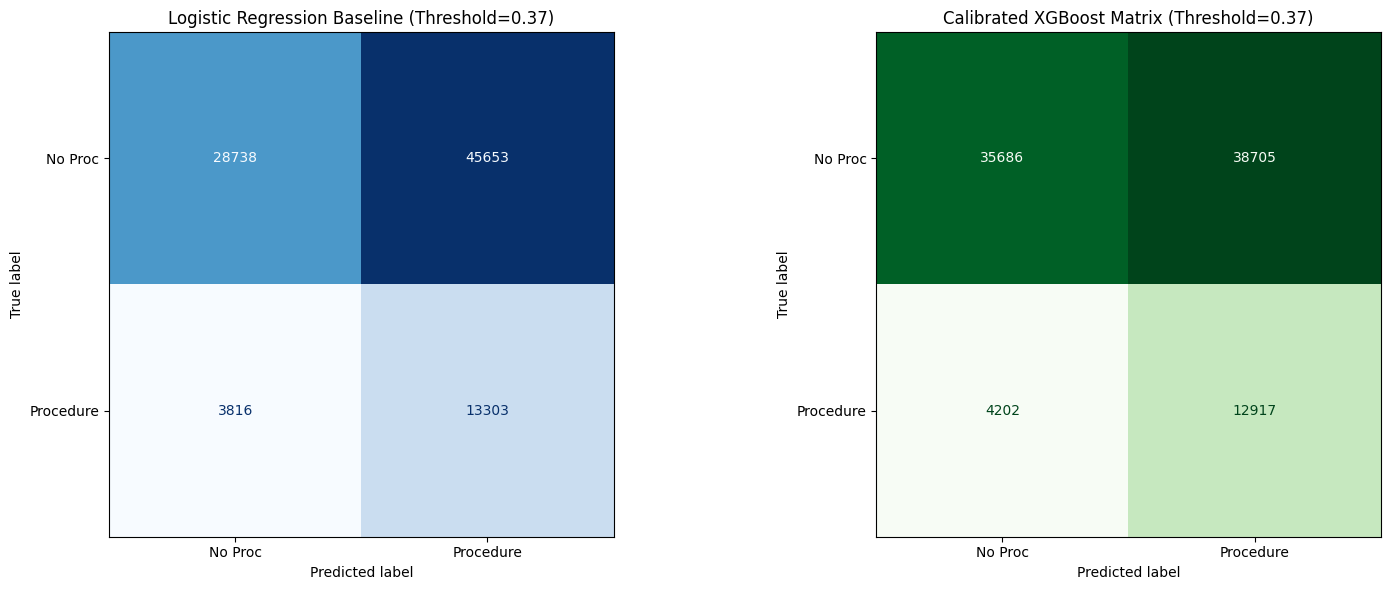

--- Summary Statistics with Threshold 0.37 ---
Baseline (LR) - TP: 13303, FP: 45653, TN: 28738, FN: 3816
XGBoost       - TP: 12917, FP: 38705, TN: 35686, FN: 4202


In [ ]:
# === CELL 8.5: Confusion Matrices with Threshold Tuning ===

# 1. Apply Clinical Threshold Tuning (Operating Point = 0.37)
triage_threshold = 0.37
print(f"Applying clinical safety threshold at {triage_threshold} to maximize Recall...")

# Using the existing pipelines from cell Z_bJHhUpGfS6
lr_probs = lr_pipeline.predict_proba(X_test)[:, 1]
xgb_probs = xgb_pipeline.predict_proba(X_test)[:, 1]

y_pred_lr_thresh = (lr_probs >= triage_threshold).astype(int)
y_pred_xgb_thresh = (xgb_probs >= triage_threshold).astype(int)

# 2. Set up the figure for side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3. Logistic Regression (Baseline) Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr_thresh)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No Proc', 'Procedure'])
disp_lr.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'Logistic Regression Baseline (Threshold={triage_threshold})')

# 4. XGBoost (Calibrated) Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb_thresh)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['No Proc', 'Procedure'])
disp_xgb.plot(cmap='Greens', ax=axes[1], colorbar=False)
axes[1].set_title(f'Calibrated XGBoost Matrix (Threshold={triage_threshold})')

plt.tight_layout()
plt.show()

# 5. Summary Statistics
print(f"--- Summary Statistics with Threshold {triage_threshold} ---")
print(f"Baseline (LR) - TP: {cm_lr[1,1]}, FP: {cm_lr[0,1]}, TN: {cm_lr[0,0]}, FN: {cm_lr[1,0]}")
print(f"XGBoost       - TP: {cm_xgb[1,1]}, FP: {cm_xgb[0,1]}, TN: {cm_xgb[0,0]}, FN: {cm_xgb[1,0]}")

In [ ]:

# Logistic Regression Baseline matching article methodology
lr_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

print("Training Logistic Regression Baseline...")
lr_pipeline.fit(X_train, y_train)

# Evaluate Baseline
y_pred_lr_default = lr_pipeline.predict(X_test)
print("\n--- Logistic Regression Baseline Results ---")
print(classification_report(y_test, y_pred_lr_default))

Training Logistic Regression Baseline...

--- Logistic Regression Baseline Results ---
              precision    recall  f1-score   support

         0.0       0.88      0.76      0.82     74391
         1.0       0.35      0.57      0.43     17119

    accuracy                           0.72     91510
   macro avg       0.62      0.66      0.63     91510
weighted avg       0.78      0.72      0.75     91510



### Explainability with SHAP (Feature Importance)

Calculating SHAP values for XGBoost...


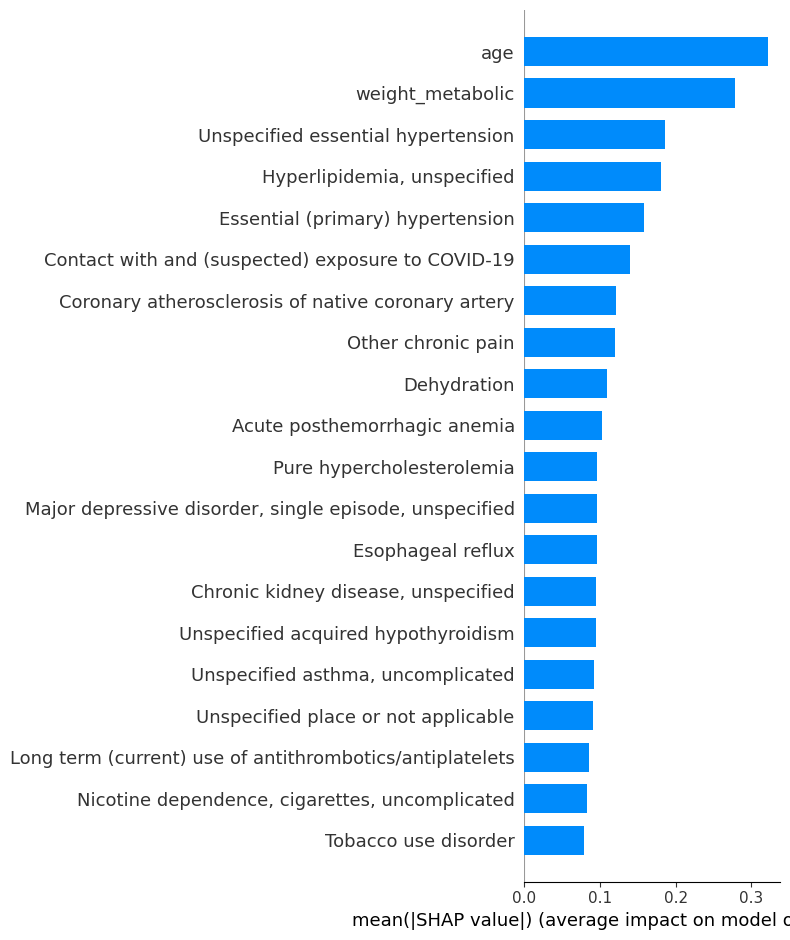

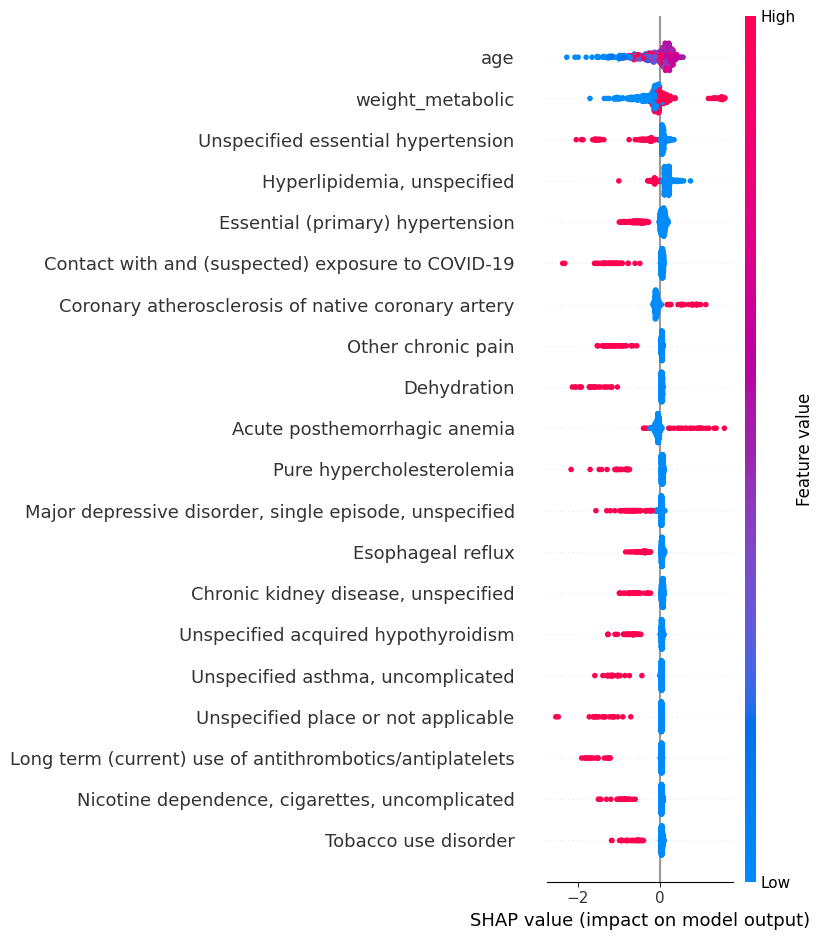

In [ ]:
# === CELL 9: Explainability with SHAP (Feature Importance) ===
print("Calculating SHAP values for XGBoost...")

# FIX: Extract the base XGBoost model from the CalibratedClassifierCV wrapper
# Since we used cv=3, we take one of the fitted estimators
calibrated_model = xgb_pipeline.named_steps['classifier']
xgb_final = calibrated_model.calibrated_classifiers_[0].estimator

# Use a sample for SHAP calculation speed
X_test_sample = X_test.sample(min(500, len(X_test)), random_state=42)

# Initialize explainer with the raw XGBoost model
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_test_sample)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=True)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, show=True)

## Gender-Stratified Performance Analysis

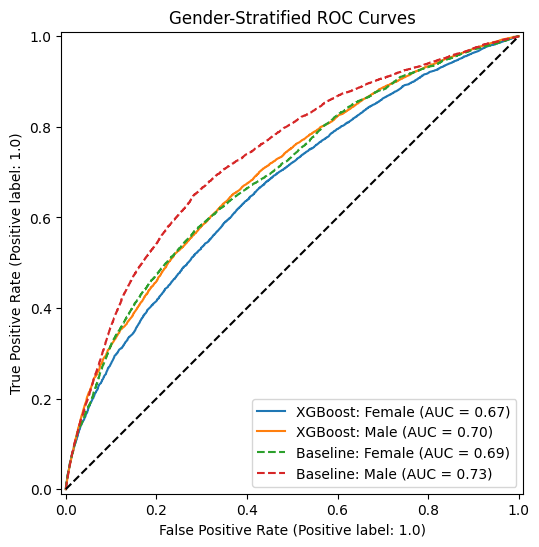

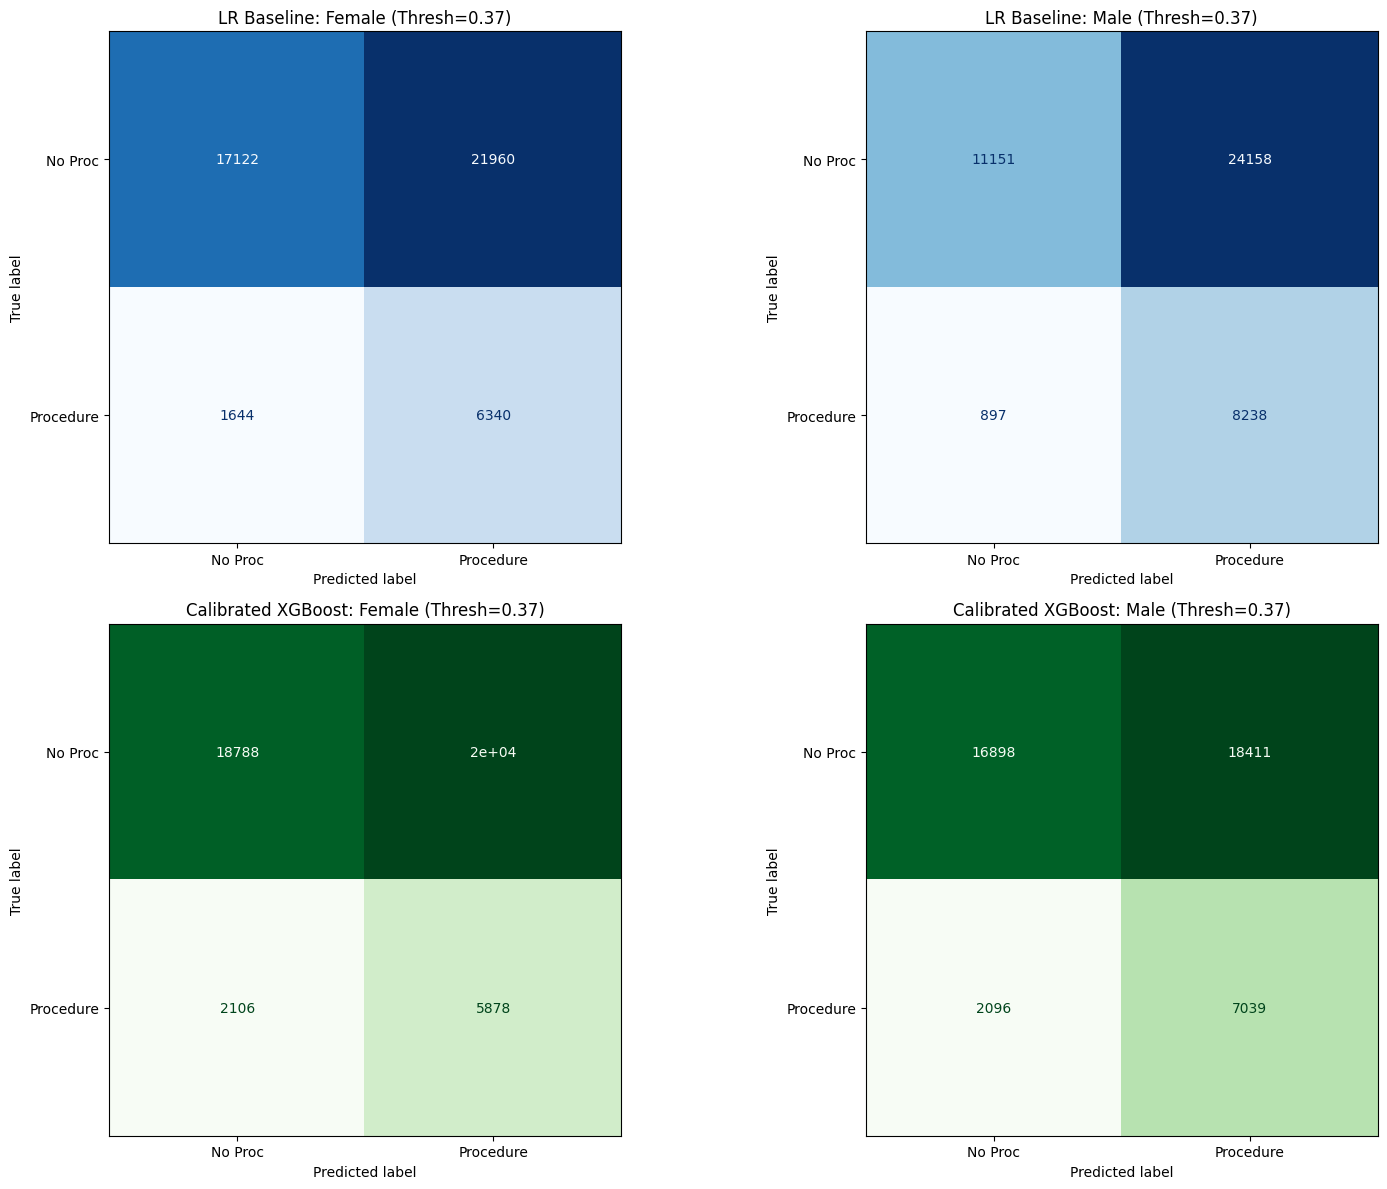

In [ ]:
# === CELL 10: Gender-Stratified Performance Analysis ===
# Create sub-cohorts
# Note: gender_binary 0=Female, 1=Male
X_test_female = X_test[X_test['gender_binary'] == 0]
y_test_female = y_test[X_test['gender_binary'] == 0]

X_test_male = X_test[X_test['gender_binary'] == 1]
y_test_male = y_test[X_test['gender_binary'] == 1]

# Predictions based on the Unified models WITH Threshold Tuning
triage_threshold = 0.37

# Fixed: Using lr_pipeline and xgb_pipeline as rf_pipeline is no longer defined
lr_probs_female = lr_pipeline.predict_proba(X_test_female)[:, 1]
lr_probs_male = lr_pipeline.predict_proba(X_test_male)[:, 1]
xgb_probs_female = xgb_pipeline.predict_proba(X_test_female)[:, 1]
xgb_probs_male = xgb_pipeline.predict_proba(X_test_male)[:, 1]

lr_preds_female = (lr_probs_female >= triage_threshold).astype(int)
lr_preds_male = (lr_probs_male >= triage_threshold).astype(int)
xgb_preds_female = (xgb_probs_female >= triage_threshold).astype(int)
xgb_preds_male = (xgb_probs_male >= triage_threshold).astype(int)

# Gender ROC Curves (XGBoost vs Baseline)
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(xgb_pipeline, X_test_female, y_test_female, ax=ax, name='XGBoost: Female')
RocCurveDisplay.from_estimator(xgb_pipeline, X_test_male, y_test_male, ax=ax, name='XGBoost: Male')
RocCurveDisplay.from_estimator(lr_pipeline, X_test_female, y_test_female, ax=ax, name='Baseline: Female', linestyle='--')
RocCurveDisplay.from_estimator(lr_pipeline, X_test_male, y_test_male, ax=ax, name='Baseline: Male', linestyle='--')
plt.title('Gender-Stratified ROC Curves')
plt.plot([0, 1], [0, 1], 'k--')
plt.show()

# 2x2 Confusion Matrices Grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

disp_lr_f = ConfusionMatrixDisplay(confusion_matrix(y_test_female, lr_preds_female), display_labels=['No Proc', 'Procedure'])
disp_lr_f.plot(cmap='Blues', ax=axes[0, 0], colorbar=False)
axes[0, 0].set_title(f'LR Baseline: Female (Thresh={triage_threshold})')

disp_lr_m = ConfusionMatrixDisplay(confusion_matrix(y_test_male, lr_preds_male), display_labels=['No Proc', 'Procedure'])
disp_lr_m.plot(cmap='Blues', ax=axes[0, 1], colorbar=False)
axes[0, 1].set_title(f'LR Baseline: Male (Thresh={triage_threshold})')

disp_xgb_f = ConfusionMatrixDisplay(confusion_matrix(y_test_female, xgb_preds_female), display_labels=['No Proc', 'Procedure'])
disp_xgb_f.plot(cmap='Greens', ax=axes[1, 0], colorbar=False)
axes[1, 0].set_title(f'Calibrated XGBoost: Female (Thresh={triage_threshold})')

disp_xgb_m = ConfusionMatrixDisplay(confusion_matrix(y_test_male, xgb_preds_male), display_labels=['No Proc', 'Procedure'])
disp_xgb_m.plot(cmap='Greens', ax=axes[1, 1], colorbar=False)
axes[1, 1].set_title(f'Calibrated XGBoost: Male (Thresh={triage_threshold})')

plt.tight_layout()
plt.show()

## Clinical Model Insight Dashboard

In [ ]:
# === CELL 11: Clinical Model Insight Dashboard ===
from sklearn.ensemble import RandomForestClassifier

# 1. Re-initialize and Train Random Forest Pipeline (Mirroring XGBoost Setup)
rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

print("Training Random Forest for Dashboard...")
rf_pipeline.fit(X_train, y_train)

def plot_feature_importance(model_type):
    plt.figure(figsize=(10, 6))

    if model_type == 'Random Forest':
        model = rf_pipeline.named_steps['classifier']
        title = 'Top 10 Feature Importances: Random Forest'
    else:
        # Extract the base XGBoost estimator from the calibration wrapper
        calibrated_model = xgb_pipeline.named_steps['classifier']
        model = calibrated_model.calibrated_classifiers_[0].estimator
        title = 'Top 10 Feature Importances: Calibrated XGBoost'

    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1][:10]
    top_features = [X_top_50.columns[i] for i in indices]
    top_importances = importances[indices]

    sns.barplot(x=top_importances, y=top_features, palette='viridis')
    plt.title(title, fontsize=14)
    plt.xlabel('Importance Score')
    plt.ylabel('Clinical Feature')
    plt.tight_layout()
    plt.show()

out = widgets.Output()

# Dropdown for model selection
model_selector = widgets.Dropdown(
    options=['XGBoost', 'Random Forest'],
    value='XGBoost',
    description='Model:',
    disabled=False,
)

def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        with out:
            clear_output(wait=True)
            plot_feature_importance(change['new'])

model_selector.observe(on_change)

dashboard_ui = widgets.VBox([
    widgets.HTML("<h2>Clinical Predictive Analytics Dashboard</h2>"),
    widgets.HTML("<p>Select a model to visualize the top diagnostic drivers for clinical interventions.</p>"),
    model_selector,
    out
])

display(dashboard_ui)
with out:
    plot_feature_importance('XGBoost')


Training Random Forest for Dashboard...


### HTML Summary Stats Tables

In [ ]:
# === CELL 12: HTML Summary Stats Tables ===
def get_summary_stats(df):
    stats = []
    age_col = [c for c in df.columns if 'age' in c.lower()][-1]
    stats.append({'Metric': 'Age (Median [IQR])', 'Value': f"{df[age_col].median():.1f} [{df[age_col].quantile(0.25):.1f} - {df[age_col].quantile(0.75):.1f}]", 'Category': 'Demographics'})

    g_mapped = df['gender_binary'].map({1: 'Male', 0: 'Female'})
    g_counts, g_pct = g_mapped.value_counts(), g_mapped.value_counts(normalize=True) * 100
    for g in g_counts.index:
        stats.append({'Metric': f'Sex: {g}', 'Value': f"{g_counts[g]:,} ({g_pct[g]:.1f}%)", 'Category': 'Demographics'})

    comorb_data = [{'Metric': col, 'Count': df[col].sum(), 'Percent': (df[col].sum() / len(df)) * 100} for col in df.columns if set(df[col].dropna().unique()).issubset({0, 1}) and col not in ['target', 'gender_binary']]
    for item in sorted(comorb_data, key=lambda x: x['Percent'], reverse=True)[:10]:
        stats.append({'Metric': item['Metric'], 'Value': f"{int(item['Count']):,} ({item['Percent']:.1f}%) ", 'Category': 'Top Comorbidities'})
    return stats

html_str = "<style>.cat-header { background-color: #ecf0f1; font-weight: bold; color: black; } .table1 { width: 100%; border-collapse: collapse; } .table1 th { background-color: #34495e; color: white; padding: 10px; } .table1 td { padding: 8px; border-bottom: 1px solid #ecf0f1; }</style>"
html_str += "<h2>Table 1: Clinical Characteristics</h2><table class='table1'><thead><tr><th>Characteristic</th><th>Value</th></tr></thead><tbody>"

current_cat = None
for s in get_summary_stats(final_dataset):
    if s['Category'] != current_cat:
        current_cat = s['Category']
        html_str += f"<tr class='cat-header'><td colspan='2'>{current_cat}</td></tr>"
    html_str += f"<tr><td>{s['Metric']}</td><td>{s['Value']}</td></tr>"

display(HTML(html_str + "</tbody></table>"))

### Clinical Model Performance Summary HTML

In [ ]:
# === CELL 13: Clinical Model Performance Summary HTML ===
import json

perf_data_total = [
    ["Random Forest", "0.7276", "0.41", "0.49", "0.45"],
    ["XGBoost", "0.7162", "0.49", "0.32", "0.39"]
]

perf_data_stratified = [
    ["Female Subgroup", "0.6845", "0.44", "0.23", "0.31"],
    ["Male Subgroup", "0.7181", "0.52", "0.39", "0.44"]
]

html_template = """
<!DOCTYPE html>
<html>
<head>
    <style>
        body { font-family: 'Inter', sans-serif; background-color: #f4f6f8; margin: 0; padding: 20px; color: black; }
        .dashboard-container { max-width: 1000px; margin: auto; }
        .card { background: white; border-radius: 12px; box-shadow: 0 4px 6px rgba(0,0,0,0.05); padding: 25px; margin-bottom: 30px; }
        table { width: 100%; border-collapse: collapse; margin-top: 15px; }
        th { text-align: left; background-color: #f8f9fa; color: black; font-weight: 600; text-transform: uppercase; padding: 12px; }
        td { padding: 12px; border-bottom: 1px solid #edf2f7; font-size: 0.9rem; color: black; }
        h2, h3 { color: black; }
    </style>
</head>
<body>
    <div class="dashboard-container">
        <h2>Predictive Modeling Performance Dashboard</h2>
        <div class="card">
            <h3>Table: Clinical Performance (Total Cohort)</h3>
            <table id="table-total">
                <thead><tr><th>Model</th><th>ROC-AUC</th><th>Precision</th><th>Recall</th><th>F1</th></tr></thead><tbody></tbody>
            </table>
        </div>
        <div class="card">
            <h3>Table: Performance (Stratified by Gender)</h3>
            <table id="table-stratified">
                <thead><tr><th>Group</th><th>ROC-AUC</th><th>Precision</th><th>Recall</th><th>F1</th></tr></thead><tbody></tbody>
            </table>
        </div>
    </div>
    <script>
        function popTable(id, data) {
            const tb = document.getElementById(id).querySelector('tbody');
            data.forEach(row => {
                const tr = document.createElement('tr');
                row.forEach(cell => { let td = document.createElement('td'); td.innerHTML = cell; tr.appendChild(td); });
                tb.appendChild(tr);
            });
        }
        popTable('table-total', """ + json.dumps(perf_data_total) + """);
        popTable('table-stratified', """ + json.dumps(perf_data_stratified) + """);
    </script>
</body>
</html>
"""
display(HTML(html_template))

Model,ROC-AUC,Precision,Recall,F1
Group,ROC-AUC,Precision,Recall,F1


## test_preprocess.py

In [ ]:
%%writefile test_preprocess.py
import pandas as pd
import pytest

def clean_demographics(df):
    return df[(df['age'] >= 18) & (df['age'] <= 100)]

def add_comorbidity_features(df):
    temp_df = df.copy()
    if 'hypertension' in temp_df.columns and 'diabetes' in temp_df.columns:
        temp_df['weight_metabolic'] = temp_df['hypertension'] + temp_df['diabetes']
        temp_df.drop(columns=['hypertension', 'diabetes'], inplace=True)
    return temp_df

def test_clean_demographics_filters_impossible_ages():
    fake_data = pd.DataFrame({'patient_id': [1, 2, 3], 'age': [45, 250, 17]})
    cleaned_data = clean_demographics(fake_data)
    assert len(cleaned_data) == 1, "The function did not drop the invalid ages!"
    assert cleaned_data['age'].iloc[0] == 45, "The remaining patient should be 45."

def test_weight_metabolic_creation():
    fake_data = pd.DataFrame({'hypertension': [1, 0], 'diabetes': [1, 1]})
    processed = add_comorbidity_features(fake_data)
    assert 'weight_metabolic' in processed.columns, "New feature not created."

Overwriting test_preprocess.py


In [ ]:
!pytest test_preprocess.py -v

============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content
plugins: anyio-4.14.2, langsmith-0.10.2, typeguard-4.5.2
collected 2 items                                                              

test_preprocess.py::test_clean_demographics_filters_impossible_ages PASSED [ 50%]
test_preprocess.py::test_weight_metabolic_creation PASSED                [100%]

============================== 2 passed in 0.64s ===============================
